In [6]:
# Environment Setup
!pip -q install wfdb==4.1.2 pillow nltk

import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import wfdb
from PIL import Image

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print("Environment setup completed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 5.3 MB/s eta 0:00:00
Environment setup completed successfully.


Dataset ingested successfully.
Dataset shape: 303 rows, 14 columns

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing values per column:
ca      4
thal    2
dtype: int64

Binary Target Distribution:
0 (No Disease)     : 164
1 (Disease Present): 139


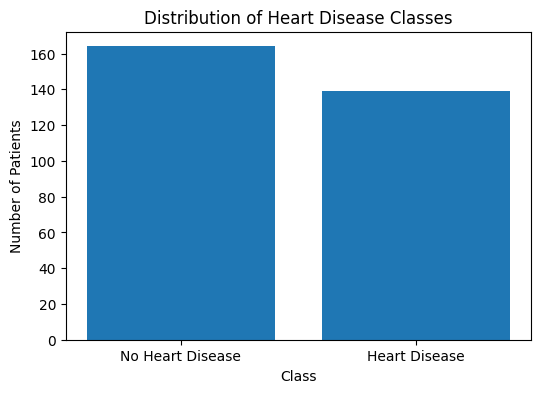


--- Baseline Model Evaluation ---
Accuracy : 0.8852
ROC-AUC  : 0.9665

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



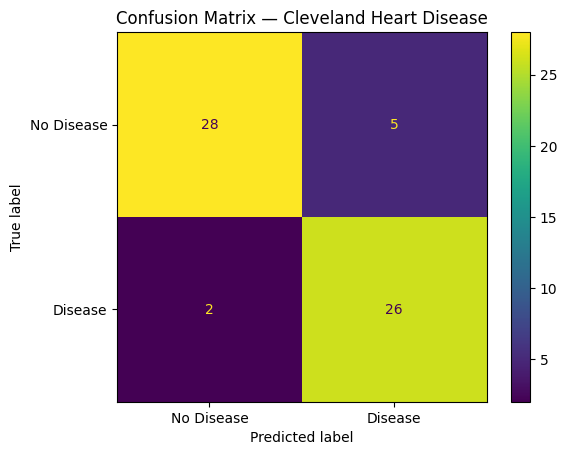

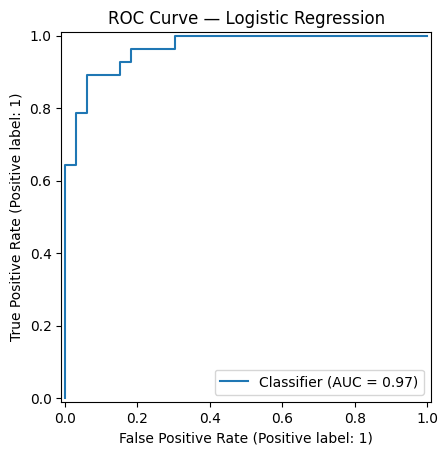

In [ ]:
# Tabular Data Ingestion

uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak", "slope",
    "ca", "thal", "target"
]

df = pd.read_csv(uci_url, names=columns, na_values="?")

print("Dataset ingested successfully.")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

print("\nFirst 5 rows:")
display(df.head())


print("\nData Types:")
print(df.dtypes)

print("\nMissing values per column:")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0])


df['target'] = (pd.to_numeric(df['target'], errors='coerce') > 0).astype(int)

class_counts = df['target'].value_counts().sort_index()

print("\nBinary Target Distribution:")
print("0 (No Disease)     :", class_counts.get(0, 0))
print("1 (Disease Present):", class_counts.get(1, 0))

plt.figure(figsize=(6, 4))
plt.bar(["No Heart Disease", "Heart Disease"], [class_counts.get(0, 0), class_counts.get(1, 0)])
plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.title("Distribution of Heart Disease Classes")
plt.show()


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay

numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n--- Baseline Model Evaluation ---")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No Disease", "Disease"])
plt.title("Confusion Matrix — Cleveland Heart Disease")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve — Logistic Regression")
plt.show()



Correlation Matrix:


,age,trestbps,chol,thalach,oldpeak,target
age,1.00,0.28,0.21,-0.39,0.20,0.22
trestbps,0.28,1.00,0.13,-0.05,0.19,0.15
chol,0.21,0.13,1.00,-0.00,0.05,0.09
thalach,-0.39,-0.05,-0.00,1.00,-0.34,-0.42
oldpeak,0.20,0.19,0.05,-0.34,1.00,0.42
target,0.22,0.15,0.09,-0.42,0.42,1.00


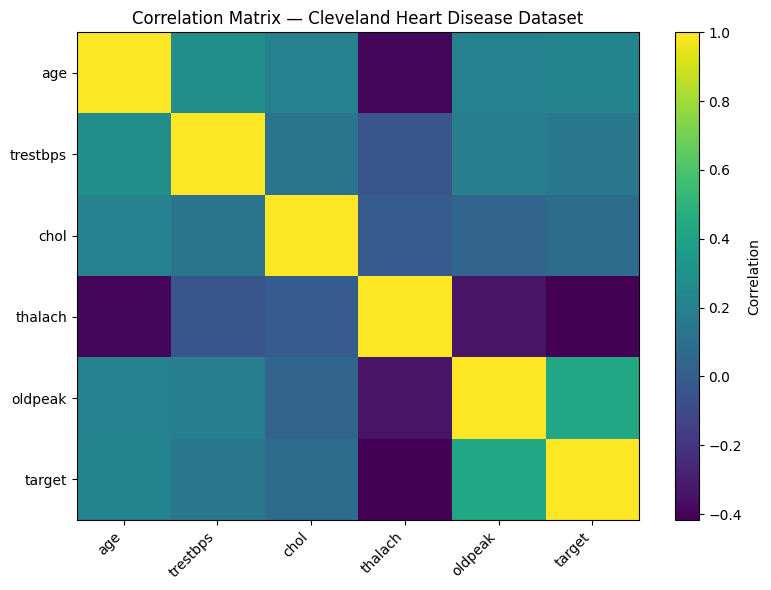

In [ ]:
correlation_columns = [
    "age", "trestbps", "chol", "thalach", "oldpeak", "target"
]

correlation_matrix = df[correlation_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(2))

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title("Correlation Matrix — Cleveland Heart Disease Dataset")
plt.tight_layout()
plt.show()

Loaded MIT-BIH Record: 100
Sampling Frequency   : 360 Hz
Total Signal Length  : 650000 samples
Channels Available   : ['MLII', 'V5']


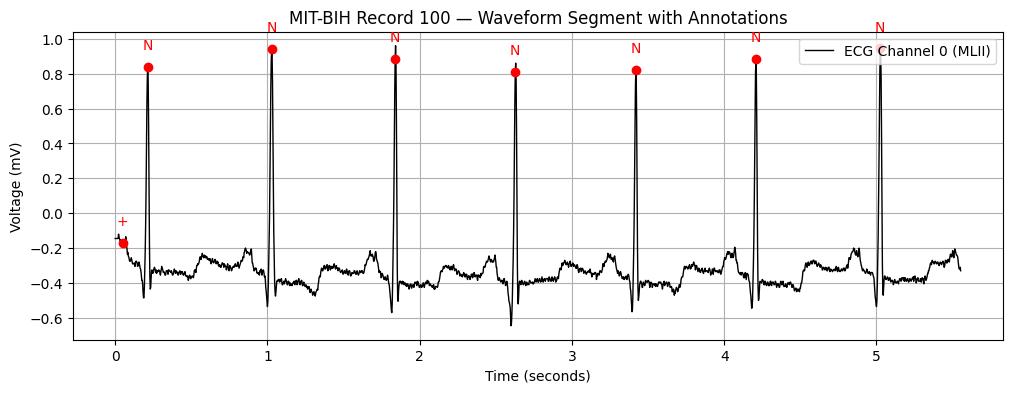


--- Heart Rate Variability (HRV) Summary ---
Mean RR Interval : 806.67 ms
Estimated Heart Rate: 74.38 BPM
SDNN (Std Dev RR): 100.66 ms


In [ ]:
# Signal Data Ingestion

record_name = '100'

record = wfdb.rdrecord(record_name, pn_dir='mitdb')
annotation = wfdb.rdann(record_name, 'atr', pn_dir='mitdb')

print(f"Loaded MIT-BIH Record: {record_name}")
print("Sampling Frequency   :", record.fs, "Hz")
print("Total Signal Length  :", record.sig_len, "samples")
print("Channels Available   :", record.sig_name)

sample_limit = 2000
signal_segment = record.p_signal[:sample_limit, 0] 
time_axis = np.arange(sample_limit) / record.fs

ann_mask = annotation.sample < sample_limit
ann_samples = annotation.sample[ann_mask]
ann_symbols = [annotation.symbol[i] for i, mask in enumerate(ann_mask) if mask]

plt.figure(figsize=(12, 4))
plt.plot(time_axis, signal_segment, color='black', linewidth=1, label='ECG Channel 0 (MLII)')

for sample, symbol in zip(ann_samples, ann_symbols):
    t = sample / record.fs
    val = record.p_signal[sample, 0]
    plt.plot(t, val, 'ro')
    plt.text(t, val + 0.1, symbol, color='red', fontsize=10, ha='center')

plt.title(f"MIT-BIH Record {record_name} — Waveform Segment with Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.legend(loc="upper right")
plt.show()

normal_beats = annotation.sample[np.array(annotation.symbol) == 'N']
rr_intervals = np.diff(normal_beats) / record.fs * 1000 

print("\n--- Heart Rate Variability (HRV) Summary ---")
print(f"Mean RR Interval : {np.mean(rr_intervals):.2f} ms")
print(f"Estimated Heart Rate: {60 / (np.mean(rr_intervals) / 1000):.2f} BPM")
print(f"SDNN (Std Dev RR): {np.std(rr_intervals):.2f} ms")

In [ ]:
# Textual Data Demonstration

clinical_note = """
Patient is a 63-year-old male presenting with acute substernal chest pain
radiating to the left arm. Symptoms started 2 hours ago during light exercise.
History of hypertension and hyperlipidemia. Resting ECG shows ST-segment elevation.
Patient reports shortness of breath and mild nausea.
"""

print("Original Clinical Note:")
print(clinical_note.strip())

tokens = word_tokenize(clinical_note.lower())

stop_words = set(stopwords.words('english'))
cleaned_tokens = [word for word in tokens if word.isalnum() and word not in stop_words]

word_counts = Counter(cleaned_tokens)

print("\nToken Extraction Results:")
print("Total words processed:", len(tokens))
print("Filtered clinical terms:", len(cleaned_tokens))

print("\nTop 5 Most Frequent Clinical Terms:")
for term, count in word_counts.most_common(5):
    print(f" - {term}: {count}")

Original Clinical Note:
Patient is a 63-year-old male presenting with acute substernal chest pain 
radiating to the left arm. Symptoms started 2 hours ago during light exercise. 
History of hypertension and hyperlipidemia. Resting ECG shows ST-segment elevation. 
Patient reports shortness of breath and mild nausea.

Token Extraction Results:
Total words processed: 47
Filtered clinical terms: 30

Top 5 Most Frequent Clinical Terms:
 - patient: 2
 - male: 1
 - presenting: 1
 - acute: 1
 - substernal: 1


# Integration Discussion

Different types of data can be used together to understand a patient's heart condition better. Tabular data gives information like age, blood pressure, and cholesterol. ECG data gives information about the heart rate and heartbeat. Text data gives details about the patient's symptoms. Medical images can also provide useful information. By combining these different types of data, a machine learning model can make a better prediction about whether a patient has heart disease.
